Analysis of different features affecting community hiding (measured with M1 and M2)


In [4]:
import os
import glob
import pandas as pd
folder = 'results_dice'
csv_files = glob.glob(os.path.join(folder, "dmon_dice_*.csv"))

# Combine all CSVs into one DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
results_df = pd.concat(df_list, ignore_index=True)

print(f'Total rows/columns: {results_df.shape}') 

Total rows/columns: (2112510, 12)


In [5]:
results_df.head()

,mu,sigma_c,target_label,target_size,b,b_percentage,p,realization,ECS,M1,M2,elapsed_time_sec
0,0.4,1.0,0,49,0,0.00,0.5,0,0.629043,0.007949,0.231335,NaN
1,0.4,1.0,0,49,3,0.01,0.5,1,0.599487,0.008913,0.202944,1.691969
2,0.4,1.0,0,49,3,0.01,0.5,2,0.594221,0.014006,0.322818,1.751480
3,0.4,1.0,0,49,3,0.01,0.5,3,0.634132,0.013072,0.433228,1.665542
4,0.4,1.0,0,49,3,0.01,0.5,4,0.598103,0.006684,0.263933,1.707951


In [6]:
import os, glob
from community_features import load_graph_with_membership, read_features_file_plain, extract_community_features
import pandas as pd

folder = "fgraphs_dice/"
all_feature_dfs = []

for edgelist_file in glob.glob(os.path.join(folder, "*.edgelist")):
    membership_file = edgelist_file.replace(".edgelist", ".membership")
    features_file   = edgelist_file.replace(".edgelist", ".features")

    G, membership = load_graph_with_membership(edgelist_file, membership_file)
    feature_map    = read_features_file_plain(features_file, nodetype=int)

    print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

    features_df = extract_community_features(G, membership, feature_map, weighted_by_other_size=False)

    # parse params from filename
    parts     = os.path.basename(edgelist_file).split("_")
    n         = int(parts[1][1:])
    mu        = float(parts[2][2:])
    sigma_c   = float(parts[3][5:])
    min_comm  = int(parts[5][4:6])

    features_df["n"]        = n
    features_df["mu"]       = mu
    features_df["sigma_c"]  = sigma_c
    features_df["min_comm"] = min_comm
    print(f"Params: n={n}, mu={mu}, sigma_c={sigma_c}, min_comm={min_comm}")

    all_feature_dfs.append(features_df)

all_features_df = pd.concat(all_feature_dfs, ignore_index=True)

# aggregate results_df by mu, sigma_c, target_label, target_size
agg_df = (
    results_df
    .groupby(['mu', 'sigma_c', 'target_label', 'target_size'], as_index=False)
    .agg({
        'M1': 'mean',
        'M2': 'mean',
        'ECS': 'mean'
    })
)
# merge agg_df with all_features_df on mu, sigma_c, target_label
full_df = pd.merge(agg_df, all_features_df, on=['target_label', 'mu', 'sigma_c'], how='left')



Loaded graph with 1000 nodes and 18039 edges
Params: n=1000, mu=0.2, sigma_c=0.5, min_comm=30
Loaded graph with 1000 nodes and 18673 edges
Params: n=1000, mu=0.5, sigma_c=1.0, min_comm=30
Loaded graph with 1000 nodes and 18510 edges
Params: n=1000, mu=0.4, sigma_c=5.0, min_comm=10
Loaded graph with 1000 nodes and 18839 edges
Params: n=1000, mu=0.5, sigma_c=2.0, min_comm=10
Loaded graph with 1000 nodes and 18839 edges
Params: n=1000, mu=0.5, sigma_c=0.5, min_comm=10
Loaded graph with 1000 nodes and 18504 edges
Params: n=1000, mu=0.3, sigma_c=0.5, min_comm=60
Loaded graph with 1000 nodes and 18039 edges
Params: n=1000, mu=0.2, sigma_c=5.0, min_comm=30
Loaded graph with 1000 nodes and 18039 edges
Params: n=1000, mu=0.2, sigma_c=0.01, min_comm=30
Loaded graph with 1000 nodes and 17969 edges
Params: n=1000, mu=0.1, sigma_c=0.01, min_comm=60
Loaded graph with 1000 nodes and 18673 edges
Params: n=1000, mu=0.5, sigma_c=2.0, min_comm=30
Loaded graph with 1000 nodes and 17777 edges
Params: n=100

In [7]:
full_df.head()

,mu,sigma_c,target_label,target_size,M1,M2,ECS,community_size,intra_edges,inter_edges,...,closeness_median,eigenvector_mean,eigenvector_std,eigenvector_median,avg_centroid_sqdist_to_others,min_centroid_sqdist_to_others,max_centroid_sqdist_to_others,nearest_comm_by_centroid,n,min_comm
0,0.01,0.01,0,15,0.012235,0.104773,0.656354,100,3089,46,...,0.317044,0.096572,0.025919,9.375061e-02,1.579233,0.905133,2.511582,2,1000,30
1,0.01,0.01,0,15,0.012235,0.104773,0.656354,15,97,3,...,0.187472,0.000004,0.000006,8.952631e-07,4.398311,2.693280,6.524729,6,1000,10
2,0.01,0.01,0,15,0.012235,0.104773,0.656354,89,1528,25,...,0.277192,0.000625,0.000562,4.736379e-04,1.394869,1.085516,2.051353,3,1000,60
3,0.01,0.01,0,89,0.012885,0.542804,0.732240,100,3089,46,...,0.317044,0.096572,0.025919,9.375061e-02,1.579233,0.905133,2.511582,2,1000,30
4,0.01,0.01,0,89,0.012885,0.542804,0.732240,15,97,3,...,0.187472,0.000004,0.000006,8.952631e-07,4.398311,2.693280,6.524729,6,1000,10


## Linear Regression
Trying to simple regression, testing the assumptions first. Turns out for community/node-based features the assumption of error normality and homoscedacity fails. 

In [174]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 
                      'mu', 'sigma_c', 'min_comm']]
X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']]
X_node_level = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']]
# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'sigma_c']]
X = X_comm_level
m1 = full_df['M1']  
m2 = full_df['M2'] 
ecs = full_df['ECS']

X_train, X_test, y_train, y_test = train_test_split(X, m1, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
for feature, coef in zip(X.columns, linreg.coef_):
    print(f"{feature}: {coef:.4f}")
print("Linear Regression Test R^2:", linreg.score(X_test, y_test))


community_size: 0.0001
inter_intra_ratio: 0.0180
comm_betweenness: 0.0009
comm_closeness: -0.0055
sigma_c: -0.0099
Linear Regression Test R^2: 0.3765164648585043


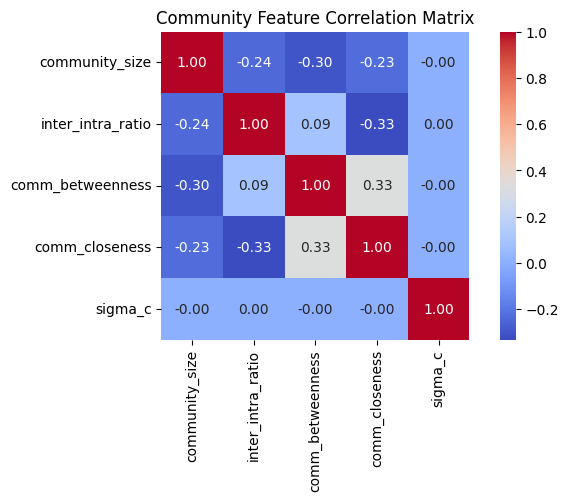

In [175]:
# plot feature covariance matrix
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 
                      'mu', 'sigma_c', 'M1', 'M2', 'ECS']].corr()
# print("Feature Correlation Matrix:")
# print(corr_matrix)
comm_corr_matrix = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']].corr()
# comm_corr_matrix = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness','sigma_c']].corr()
# comm_corr_matrix = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']].corr()

plt.figure(figsize=(8, 4))
sns.heatmap(comm_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True )
plt.title("Community Feature Correlation Matrix")
plt.show()

In [176]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
for col, v in zip(X.columns, vif):
    print(f"{col}: VIF={v:.2f}")
# VIF > 5 (some say 10) indicates multicollinearity problem


community_size: VIF=1.95
inter_intra_ratio: VIF=1.40
comm_betweenness: VIF=1.43
comm_closeness: VIF=1.78
sigma_c: VIF=1.59


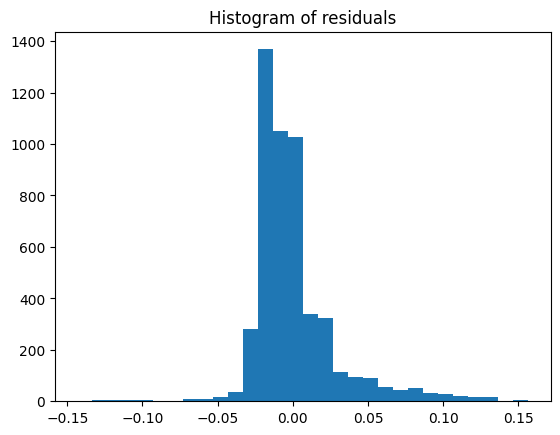

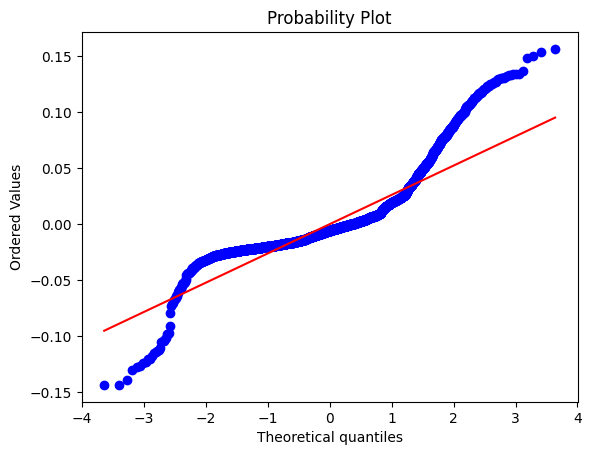

Shapiro-Wilk p-value: 3.7572796640294984e-60
Kolmogorov-Smirnov p-value: 2.4840224792233787e-127


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5058.
  res = hypotest_fun_out(*samples, **kwds)


In [177]:
import scipy.stats as stats

residuals = m1 - linreg.predict(X_scaled)

# Histogram
plt.hist(residuals, bins=30)
plt.title("Histogram of residuals")
plt.show()

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

# Shapiro-Wilk test
print("Shapiro-Wilk p-value:", stats.shapiro(residuals)[1])
# p > 0.05 means residuals are likely normal

# Kolmogorov-Smirnov test
ks_stat, ks_p_value = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print("Kolmogorov-Smirnov p-value:", ks_p_value)
# p > 0.05 means residuals are likely normal

In [178]:
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson:", durbin_watson(residuals))
# Value ~2 is good; <1 or >3 means possible autocorrelation


Durbin-Watson: 0.8114024106411575


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant to X for statsmodels
X_const = sm.add_constant(X)
model = sm.OLS(m1, X_const).fit()
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("Breusch-Pagan test p-value:", bp_test[1])
# p < 0.05 means heteroscedasticity is present (Unequal Variance of Errors)


Breusch-Pagan test p-value: 2.048984944920784e-219


## Random Forest Regression and Shapley Values

______________________

Running Random Forest Regression (for simplicity) then analysis of feature importance (GINI-based and Shap). Feature importance is performed to analyze the effect of certain features on M1 and M2.

In [13]:
# print list of columns 
print("Columns in full_df:", full_df.columns.tolist())
# all_features_list = [item for item in full_df.columns.tolist() if not in ['mu', 'sigma_c', 'min_comm', 'target_label', 'target_size', 'M1', 'M2', 'ECS'] ]
all_features_list = [item for item in full_df.columns.tolist() if item not in ['n', 'mu', 'sigma_c', 'min_comm', 'target_label', 'target_size', 'M1', 'M2', 'ECS'] ]
print("All features:", all_features_list)
# features_list = ['community_size', 'inter_intra_ratio',
#                  'comm_degree_centrality', 'comm_betweenness', 'comm_closeness',
#                  'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean',
#                  'avg_centroid_d2_to_others', 'avg_expected_d2_to_others',
#                  'min_centroid_d2_to_others', 'max_centroid_d2_to_others', 'nearest_comm_by_centroid']
features_list = ['community_size', 'inter_intra_ratio',
                 'comm_degree_centrality', 'comm_betweenness', 'comm_closeness',
                 'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 
                 'avg_centroid_sqdist_to_others']
#   'min_centroid_sqdist_to_others', 'max_centroid_sqdist_to_others', 'nearest_comm_by_centroid']

Columns in full_df: ['mu', 'sigma_c', 'target_label', 'target_size', 'M1', 'M2', 'ECS', 'community_size', 'intra_edges', 'inter_edges', 'inter_intra_ratio', 'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 'degree_centrality_mean', 'degree_centrality_std', 'degree_centrality_median', 'betweenness_mean', 'betweenness_std', 'betweenness_median', 'closeness_mean', 'closeness_std', 'closeness_median', 'eigenvector_mean', 'eigenvector_std', 'eigenvector_median', 'avg_centroid_sqdist_to_others', 'min_centroid_sqdist_to_others', 'max_centroid_sqdist_to_others', 'nearest_comm_by_centroid', 'n', 'min_comm']
All features: ['community_size', 'intra_edges', 'inter_edges', 'inter_intra_ratio', 'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 'degree_centrality_mean', 'degree_centrality_std', 'degree_centrality_median', 'betweenness_mean', 'betweenness_std', 'betweenness_median', 'closeness_mean', 'closeness_std', 'closeness_median', 'eigenvector_mean', 'eigenvector_std

In [14]:
# Feature label mapping for clean axis/titles
feature_labels = {
    'avg_centroid_sqdist_to_others': r'$\overline{d^2}(C^\star)$',
    'community_size': r'$|C^\star|$',
    'inter_intra_ratio': r'$|E_{\text{intra}}|/|E_{\text{inter}}|$',
    'degree_centrality_mean': r'$\overline{k}_u$',
    'comm_degree_centrality': r'$k_{C^\star}$',
    'betweenness_mean': r'$\overline{betw}(u)$',
    'comm_betweenness': r'$betw(C^\star)$',
    'closeness_mean': r'$\overline{clos}(u)$',
    'comm_closeness': r'$clos(C^\star)$'
}

def get_feature_label(col):
    return feature_labels.get(col, col)


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean',  'sigma_c']]
X = full_df[features_list ]
# X = X.rename(columns=feature_labels)

# X = full_df[features_list]

# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c', 'min_comm']]
# X_node_level = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c', 'min_comm']]
# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'sigma_c']]
# X = X_node_level

m1 = full_df['M1']  
m2 = full_df['M2'] 
ecs = full_df['ECS']

X_train_m1, X_test, y_train, y_test = train_test_split(X, m1, test_size=0.2, random_state=42)

# m1_reg = RandomForestRegressor(n_estimators=100, random_state=42)
m1_reg = RandomForestRegressor()
m1_reg.fit(X_train_m1, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, m1_reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", m1_reg.score(X_test, y_test))
print("Feature importances for M1 using RF Gini:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")


Test R^2: 0.5532363779846992
Feature importances for M1 using RF Gini:
inter_intra_ratio: 0.5194
avg_centroid_sqdist_to_others: 0.3614
closeness_mean: 0.0307
comm_closeness: 0.0242
degree_centrality_mean: 0.0186
betweenness_mean: 0.0182
community_size: 0.0180
comm_betweenness: 0.0081
comm_degree_centrality: 0.0014


Test R^2 (M1): 0.5532363779846992

=== Normalized SHAP Feature Importances (sum=1) ===
inter_intra_ratio              0.487 (cumulative: 0.487)
avg_centroid_sqdist_to_others  0.373 (cumulative: 0.860)
closeness_mean                 0.047 (cumulative: 0.907)
comm_closeness                 0.025 (cumulative: 0.932)
degree_centrality_mean         0.021 (cumulative: 0.953)
community_size                 0.018 (cumulative: 0.971)
betweenness_mean               0.017 (cumulative: 0.988)
comm_betweenness               0.010 (cumulative: 0.998)
comm_degree_centrality         0.002 (cumulative: 1.000)


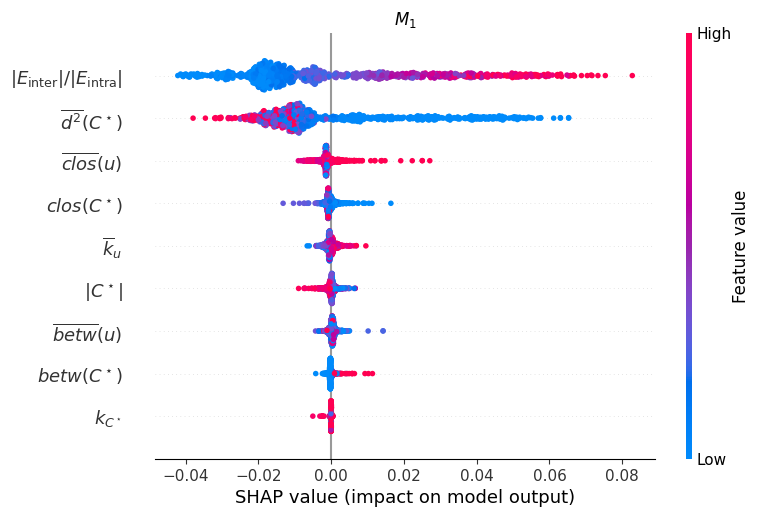

In [39]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# # Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(m1_reg)

# # Use a small background sample from TRAIN for the SHAP baseline
# background = shap.sample(X_train_m1, 200, random_state=42)

# # Interventional TreeExplainer is recommended for correlated features
# explainer = shap.TreeExplainer(
#     m1_reg,
#     data=background,
#     feature_perturbation="interventional"
# )


# Calculate SHAP values for the training dataset
# shap_values_m1 = explainer.shap_values(X_train_m1)
# features = X_train_m1.columns.tolist()
shap_values_m1 = explainer.shap_values(X_test)
features = X_test.columns.tolist()

# Feature label mapping for clean axis/titles
feature_labels = {
    'avg_centroid_sqdist_to_others': r'$\overline{d^2}(C^\star)$',
    'community_size': r'$|C^\star|$',
    'inter_intra_ratio': r'$|E_{\text{inter}}|/|E_{\text{intra}}|$',
    'degree_centrality_mean': r'$\overline{k}_u$',
    'comm_degree_centrality': r'$k_{C^\star}$',
    'betweenness_mean': r'$\overline{betw}(u)$',
    'comm_betweenness': r'$betw(C^\star)$',
    'closeness_mean': r'$\overline{clos}(u)$',
    'comm_closeness': r'$clos(C^\star)$'
}

def get_feature_label(col):
    return feature_labels.get(col, col)

# Use mapped labels for SHAP summary plot
features_pretty = [get_feature_label(f) for f in features]

# Compute mean absolute SHAP value per feature (i.e., global importance)
mean_abs_shap = np.abs(shap_values_m1).mean(axis=0)
total_shap = mean_abs_shap.sum()
normalized_shap = mean_abs_shap / total_shap  # each now represents a fraction of total importance

shap_importances = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap,
    'fraction_of_total': normalized_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Compute cumulative fraction (for additive interpretation)
shap_importances['cumulative_fraction'] = shap_importances['fraction_of_total'].cumsum()
print("Test R^2 (M1):", m1_reg.score(X_test, y_test))

# Print ranked SHAP importances with normalized fractions
print("\n=== Normalized SHAP Feature Importances (sum=1) ===")
for _, row in shap_importances.iterrows():
    print(f"{row['feature']:<30} "
          f"{row['fraction_of_total']:.3f} "
          f"(cumulative: {row['cumulative_fraction']:.3f})")

shap.summary_plot(shap_values_m1, X_test, feature_names=features_pretty, show=False)
plt.title(r"$M_1$")
plt.show()

In [49]:
# # For waterfall plot: select ONE sample
# sample_idx = 10  # or any index you want
# sample_shap_values = shap_values_m1[sample_idx]
# sample_features = X_train_m1.iloc[sample_idx]

# # Waterfall plot (for a single sample)
# shap.plots.waterfall(shap.Explanation(values=sample_shap_values, 
#                                       base_values=explainer.expected_value, 
#                                       data=sample_features, 
#                                       feature_names=features))
# plt.show()

In [45]:
# import shap
# import matplotlib.pyplot as plt
# feature_index = 1  # Change this to the index of the feature you want to plot

# shap.dependence_plot(feature_index, shap_values_m1, X_train, feature_names=features)
# plt.show()

In [46]:
# import shap
# import matplotlib.pyplot as plt

# # Assuming 'explainer' and 'shap_values' are available
# shap.decision_plot(explainer.expected_value[0], shap_values_m1[0], feature_names=features)
# plt.show()

In [135]:
# import shap
# import matplotlib.pyplot as plt

# features = X_train.columns.tolist()

# shap.summary_plot(shap_values, X_train, feature_names=features, plot_type="bar")
# plt.show()

In [41]:
X_train_m2, X_test, y_train, y_test = train_test_split(X, m2, test_size=0.2, random_state=42)

m2_reg = RandomForestRegressor()
m2_reg.fit(X_train_m2, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, m2_reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", m2_reg.score(X_test, y_test))
# Built-in feature importance (Gini Importance)
print("Feature importances for M2:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Test R^2: 0.6966137587750603
Feature importances for M2:
inter_intra_ratio: 0.5413
avg_centroid_sqdist_to_others: 0.3093
closeness_mean: 0.0731
comm_closeness: 0.0268
community_size: 0.0152
degree_centrality_mean: 0.0144
betweenness_mean: 0.0137
comm_betweenness: 0.0050
comm_degree_centrality: 0.0012


Test R^2: 0.6966137587750603

=== Normalized SHAP Feature Importances (sum=1) ===
inter_intra_ratio              0.452 (cumulative: 0.452)
avg_centroid_sqdist_to_others  0.334 (cumulative: 0.787)
closeness_mean                 0.124 (cumulative: 0.911)
comm_closeness                 0.037 (cumulative: 0.948)
community_size                 0.018 (cumulative: 0.965)
degree_centrality_mean         0.015 (cumulative: 0.980)
betweenness_mean               0.012 (cumulative: 0.992)
comm_betweenness               0.006 (cumulative: 0.998)
comm_degree_centrality         0.002 (cumulative: 1.000)


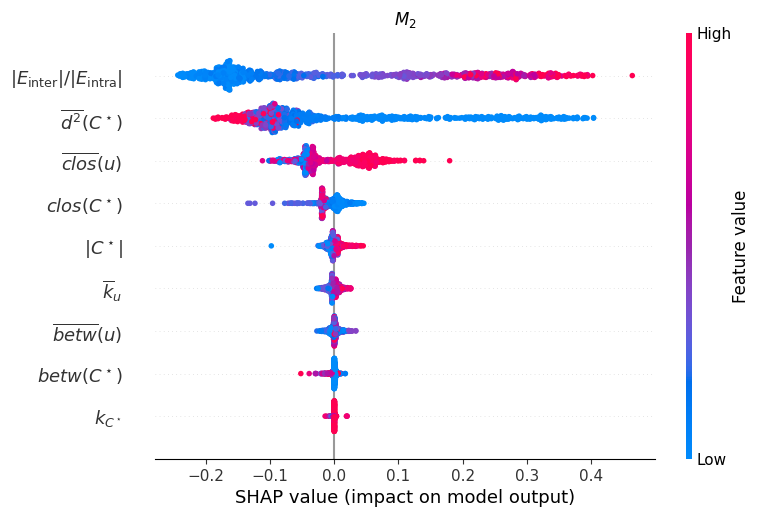

In [42]:
import shap

explainer = shap.TreeExplainer(m2_reg)

# Calculate SHAP values for the training dataset
# shap_values_m2 = explainer.shap_values(X_train_m2)
# features = X_train_m2.columns.tolist()

# Calulate SHAP values on the test set
shap_values_m2 = explainer.shap_values(X_test)
features = X_test.columns.tolist()

# Use mapped labels for SHAP summary plot
features_pretty = [get_feature_label(f) for f in features]

# Compute mean absolute SHAP value per feature (i.e., global importance)
mean_abs_shap = np.abs(shap_values_m2).mean(axis=0)
total_shap = mean_abs_shap.sum()
normalized_shap = mean_abs_shap / total_shap  # each now represents a fraction of total importance

shap_importances = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap,
    'fraction_of_total': normalized_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Compute cumulative fraction (for additive interpretation)
shap_importances['cumulative_fraction'] = shap_importances['fraction_of_total'].cumsum()
print("Test R^2:", m2_reg.score(X_test, y_test))
# Print ranked SHAP importances with normalized fractions
print("\n=== Normalized SHAP Feature Importances (sum=1) ===")
for _, row in shap_importances.iterrows():
    print(f"{row['feature']:<30} "
          f"{row['fraction_of_total']:.3f} "
          f"(cumulative: {row['cumulative_fraction']:.3f})")

shap.summary_plot(shap_values_m2, X_test, feature_names=features_pretty, show= False)
plt.title(r"$M_2$")
plt.show()

In [51]:
# For waterfall plot: select ONE sample
# sample_idx = 5  # or any index you want
# sample_shap_values = shap_values_m2[sample_idx]
# sample_features = X_train_m2.iloc[sample_idx]

# # Waterfall plot (for a single sample)
# shap.plots.waterfall(shap.Explanation(values=sample_shap_values, 
#                                       base_values=explainer.expected_value, 
#                                       data=sample_features, 
#                                       feature_names=features))
# plt.show()

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, ecs, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", reg.score(X_test, y_test))
print("Feature importances for ECS:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Test R^2: 0.9577352985194332
Feature importances for ECS:
inter_intra_ratio: 0.5442
avg_centroid_sqdist_to_others: 0.3707
closeness_mean: 0.0530
comm_closeness: 0.0166
eigenvector_mean: 0.0050
degree_centrality_mean: 0.0041
betweenness_mean: 0.0026
community_size: 0.0021
comm_betweenness: 0.0015
comm_degree_centrality: 0.0003



=== Normalized SHAP Feature Importances (sum=1) ===
inter_intra_ratio              0.443 (cumulative: 0.443)
avg_centroid_sqdist_to_others  0.397 (cumulative: 0.840)
closeness_mean                 0.103 (cumulative: 0.943)
comm_closeness                 0.025 (cumulative: 0.968)
eigenvector_mean               0.011 (cumulative: 0.980)
degree_centrality_mean         0.009 (cumulative: 0.988)
betweenness_mean               0.004 (cumulative: 0.993)
community_size                 0.004 (cumulative: 0.997)
comm_betweenness               0.003 (cumulative: 0.999)
comm_degree_centrality         0.001 (cumulative: 1.000)


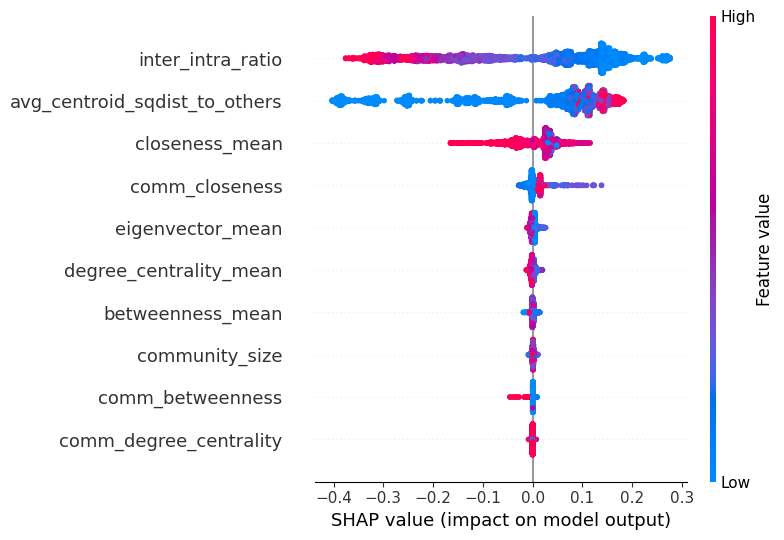

In [ ]:
import shap

explainer = shap.TreeExplainer(reg)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(X_train)
features = X_train.columns.tolist()

# Compute mean absolute SHAP value per feature (i.e., global importance)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
total_shap = mean_abs_shap.sum()
normalized_shap = mean_abs_shap / total_shap  # each now represents a fraction of total importance

shap_importances = pd.DataFrame({
    'feature': X_train_m1.columns,
    'mean_abs_shap': mean_abs_shap,
    'fraction_of_total': normalized_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Compute cumulative fraction (for additive interpretation)
shap_importances['cumulative_fraction'] = shap_importances['fraction_of_total'].cumsum()

# Print ranked SHAP importances with normalized fractions
print("\n=== Normalized SHAP Feature Importances (sum=1) ===")
for _, row in shap_importances.iterrows():
    print(f"{row['feature']:<30} "
          f"{row['fraction_of_total']:.3f} "
          f"(cumulative: {row['cumulative_fraction']:.3f})")

shap.summary_plot(shap_values, X_train, feature_names=features)
plt.show()